In [2]:
import tensorflow as tf
import numpy as np
import os
from pathlib import Path

In [3]:
data_dir = Path(r"c:\Users\benke\Downloads\archive\Fruit And Vegetable Diseases Dataset")

print(data_dir.exists())
print(list(data_dir.iterdir())[:10])

True
[WindowsPath('c:/Users/benke/Downloads/archive/Fruit And Vegetable Diseases Dataset/Apple_Data'), WindowsPath('c:/Users/benke/Downloads/archive/Fruit And Vegetable Diseases Dataset/Banana__Healthy'), WindowsPath('c:/Users/benke/Downloads/archive/Fruit And Vegetable Diseases Dataset/Banana__Rotten'), WindowsPath('c:/Users/benke/Downloads/archive/Fruit And Vegetable Diseases Dataset/Bellpepper__Healthy'), WindowsPath('c:/Users/benke/Downloads/archive/Fruit And Vegetable Diseases Dataset/Bellpepper__Rotten'), WindowsPath('c:/Users/benke/Downloads/archive/Fruit And Vegetable Diseases Dataset/Carrot__Healthy'), WindowsPath('c:/Users/benke/Downloads/archive/Fruit And Vegetable Diseases Dataset/Carrot__Rotten'), WindowsPath('c:/Users/benke/Downloads/archive/Fruit And Vegetable Diseases Dataset/Cucumber__Healthy'), WindowsPath('c:/Users/benke/Downloads/archive/Fruit And Vegetable Diseases Dataset/Cucumber__Rotten'), WindowsPath('c:/Users/benke/Downloads/archive/Fruit And Vegetable Disease

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Resizing,
    Rescaling,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense
)

#Pfad zum Ordner (habe unterordner für nur äpflel erstellt)
data_dir = Path(r"c:/Users/benke/Downloads/archive/Fruit And Vegetable Diseases Dataset/Apple_Data")

img_size = (64, 64)
batch_size = 32
seed = 42

# 70 % Training 15 % val 15 % test
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names

temp_batches = temp_ds.cardinality().numpy()
val_batches = temp_batches // 2
val_ds = temp_ds.take(val_batches)
test_ds = temp_ds.skip(val_batches)

print("Klassen:", class_names)
print("Training Batches:", train_ds.cardinality().numpy())
print("Validation Batches:", val_ds.cardinality().numpy())
print("Test Batches:", test_ds.cardinality().numpy())

Found 5363 files belonging to 2 classes.
Using 3755 files for training.
Found 5363 files belonging to 2 classes.
Using 1608 files for validation.
Klassen: ['Apple__Healthy', 'Apple__Rotten']
Training Batches: 118
Validation Batches: 25
Test Batches: 26


In [ ]:
from tensorflow.keras.applications import VGG16
baseModel = VGG16(include_top=False, weights='imagenet', input_shape=(64,64,3))
for layer in baseModel.layers:
    layer.trainable = False

In [15]:
from tensorflow.keras.applications.vgg16 import preprocess_input

model = Sequential()

model.add(Resizing(64, 64))

# Vortrainiertes Modell hinzufügen
model.add(baseModel)
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(2, activation='softmax'))

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_3 (Resizing)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 2, 2, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [7]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint
es=EarlyStopping(patience=3)
mc=ModelCheckpoint(filepath='bestModel.keras',save_best_only=True)

In [16]:
mc=ModelCheckpoint(filepath='bestModel.keras',save_best_only=True)
model.fit(train_ds,validation_data=val_ds,epochs=10, callbacks=[es,mc])

Epoch 1/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 75s 621ms/step - accuracy: 0.8921 - loss: 2.2833 - val_accuracy: 0.9475 - val_loss: 0.7439
Epoch 2/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 68s 568ms/step - accuracy: 0.9606 - loss: 0.3710 - val_accuracy: 0.9212 - val_loss: 1.1287
Epoch 3/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 61s 517ms/step - accuracy: 0.9742 - loss: 0.1749 - val_accuracy: 0.9500 - val_loss: 0.5019


In [17]:
model.load_weights('bestModel.keras')
score = model.evaluate(test_ds)

26/26 ━━━━━━━━━━━━━━━━━━━━ 14s 466ms/step - accuracy: 0.9579 - loss: 0.3475


In [18]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 921ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 624ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 739ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 875ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 508ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 634ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 521ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

[[329  17]
 [ 18 444]]


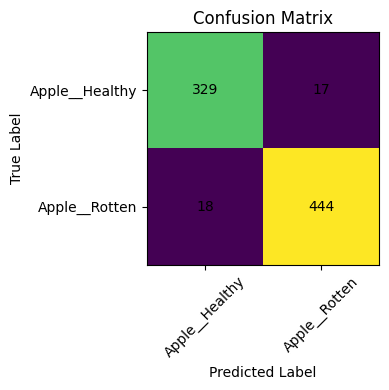

In [19]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_true, y_pred)

print(cm)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
plt.yticks(np.arange(len(class_names)), class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

In [12]:
#!python -m pip install scikit-learn